# XGBoost Multilabel Cascade Prediction
**Binary Relevance with `scale_pos_weight` for class imbalance**

This notebook trains one XGBoost binary classifier per cascade label and provides
visibility into every stage: data exploration, class imbalance, training curves,
feature importance, threshold tuning, and final evaluation.

In [52]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss, jaccard_score,
    precision_recall_curve, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

%matplotlib inline

## 1. Load Prepared Data

In [53]:
DATA_DIR = Path('../chronological_prepared_data')

X_train = np.load(DATA_DIR / 'X_train.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
target_names  = metadata['target_names']

print(f"Train : {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]:,}  samples")
print(f"Labels: {len(target_names)}")
print(f"Split : {metadata.get('split_type', 'unknown')}")

Train : 773,952 samples, 165 features
Test  : 193,489  samples
Labels: 26
Split : chronological


## 2. Explore Label Distributions & Class Imbalance
Understanding how skewed each label is drives the choice of `scale_pos_weight`.

In [54]:
train_counts = y_train.sum(axis=0)
test_counts  = y_test.sum(axis=0)
train_total  = y_train.shape[0]
test_total   = y_test.shape[0]

label_df = pd.DataFrame({
    'label': target_names,
    'train_pos': train_counts.astype(int),
    'test_pos':  test_counts.astype(int),
    'train_pct': train_counts / train_total * 100,
    'test_pct':  test_counts / test_total * 100,
    'imbalance_ratio': (train_total - train_counts) / np.maximum(train_counts, 1)
}).sort_values('train_pos', ascending=False).reset_index(drop=True)

label_df.style.format({
    'train_pos': '{:,.0f}', 'test_pos': '{:,.0f}',
    'train_pct': '{:.2f}%', 'test_pct': '{:.2f}%',
    'imbalance_ratio': '{:.1f}:1'
}).bar(subset=['train_pct'], color='#5fba7d')

,label,train_pos,test_pos,train_pct,test_pct,imbalance_ratio
0,Thunderstorm Wind,"38,123","9,688",4.93%,5.01%,19.3:1
1,Hail,"37,092","9,749",4.79%,5.04%,19.9:1
2,Flash Flood,"34,048","9,973",4.40%,5.15%,21.7:1
3,Flood,"8,760","1,869",1.13%,0.97%,87.4:1
4,Tornado,"8,409","3,125",1.09%,1.62%,91.0:1
5,Lightning,"5,386","1,101",0.70%,0.57%,142.7:1
6,Excessive Heat,"2,212","3,070",0.29%,1.59%,348.9:1
7,Heat,"1,788","2,406",0.23%,1.24%,431.9:1
8,Extreme Cold/Wind Chill,"1,517",169,0.20%,0.09%,509.2:1
9,Debris Flow,"1,277",292,0.16%,0.15%,605.1:1


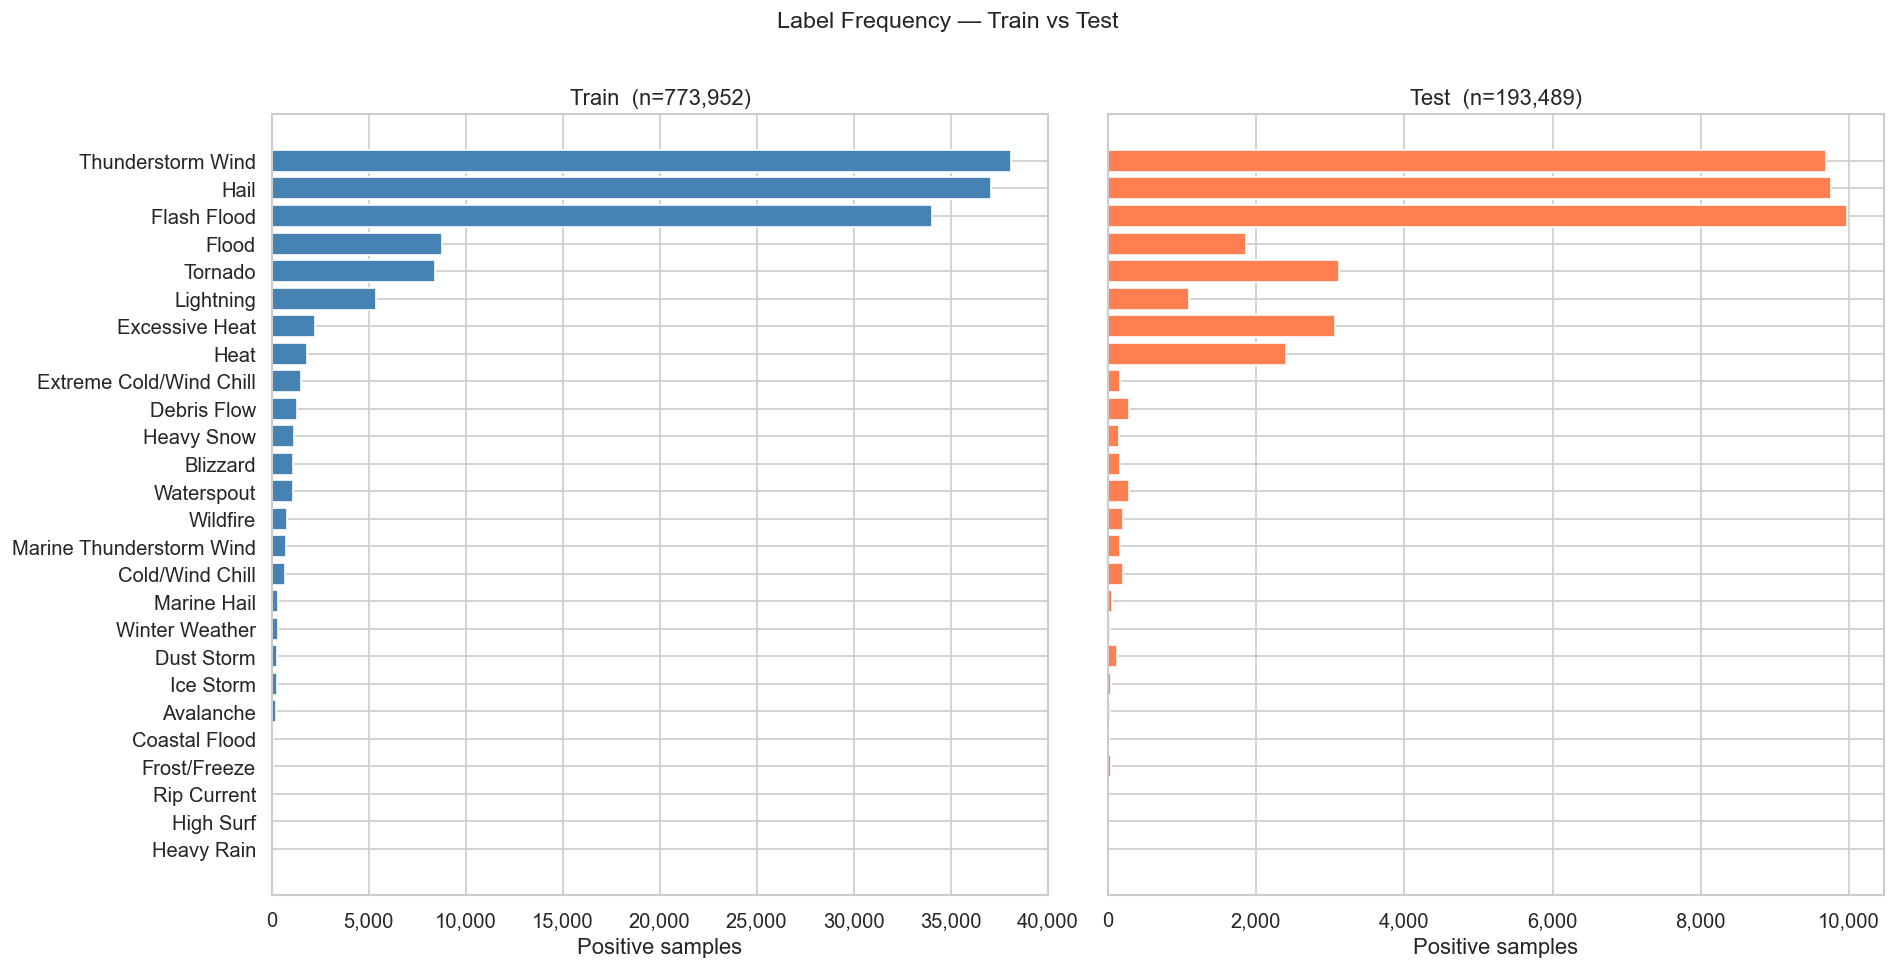

In [55]:
# --- Label frequency: train vs test side-by-side ---
sorted_df = label_df.sort_values('train_pos', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

axes[0].barh(sorted_df['label'], sorted_df['train_pos'], color='steelblue')
axes[0].set_xlabel('Positive samples')
axes[0].set_title(f'Train  (n={train_total:,})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(sorted_df['label'], sorted_df['test_pos'], color='coral')
axes[1].set_xlabel('Positive samples')
axes[1].set_title(f'Test  (n={test_total:,})')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Label Frequency — Train vs Test', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

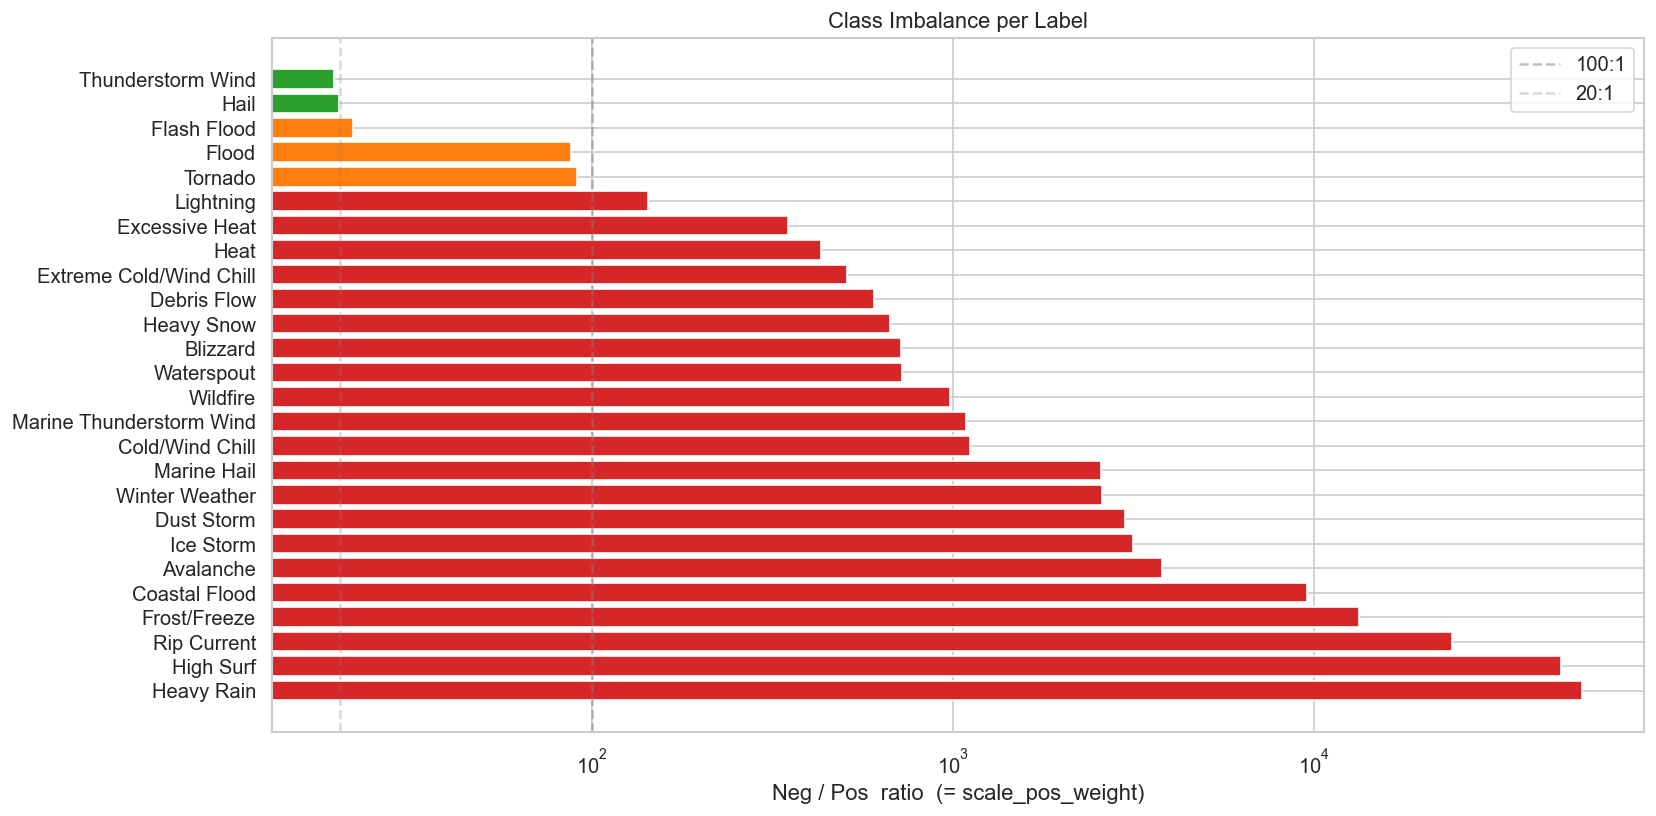

In [56]:
# --- Imbalance ratio (= scale_pos_weight that will be used) ---
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#d62728' if r > 100 else '#ff7f0e' if r > 20 else '#2ca02c'
          for r in sorted_df['imbalance_ratio']]
ax.barh(sorted_df['label'], sorted_df['imbalance_ratio'], color=colors)
ax.set_xlabel('Neg / Pos  ratio  (= scale_pos_weight)')
ax.set_title('Class Imbalance per Label')
ax.set_xscale('log')
ax.axvline(x=100, ls='--', color='gray', alpha=.5, label='100:1')
ax.axvline(x=20,  ls='--', color='gray', alpha=.3, label='20:1')
ax.legend()
plt.tight_layout()
plt.show()

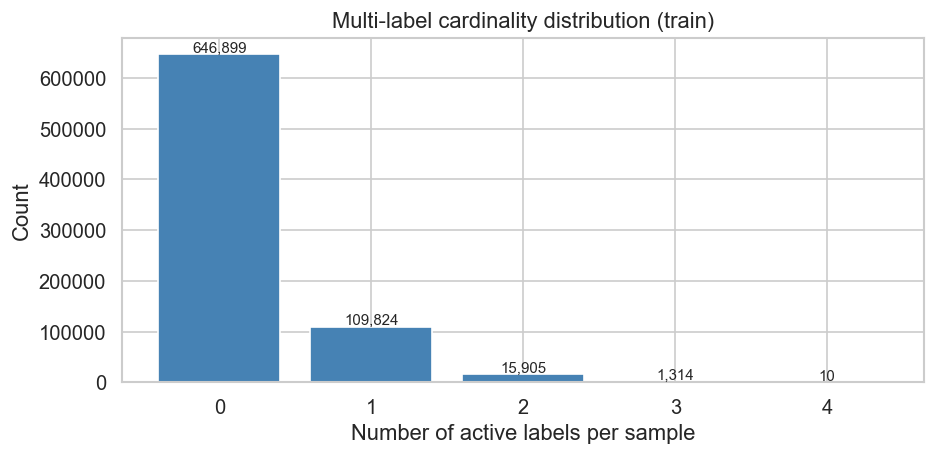

Mean labels per sample: 0.19
Samples with 0 labels : 646,899  (83.6%)


In [57]:
# --- Multi-label co-occurrence ---
labels_per_sample = y_train.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
counts = pd.Series(labels_per_sample).value_counts().sort_index()
ax.bar(counts.index.astype(int), counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of active labels per sample')
ax.set_ylabel('Count')
ax.set_title('Multi-label cardinality distribution (train)')
for i, (x, v) in enumerate(zip(counts.index, counts.values)):
    ax.text(x, v + train_total * 0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Mean labels per sample: {labels_per_sample.mean():.2f}")
print(f"Samples with 0 labels : {(labels_per_sample == 0).sum():,}  "
      f"({(labels_per_sample == 0).mean()*100:.1f}%)")

## 3. Hyperparameter Tuning + Training

**Approach**: Quick randomized search on the top-2 labels (most training
positives), then train all labels with the best-found hyperparameters.

**Key design decisions:**
- **Chronological val split**: The last 10% of training data forms the
  validation set — strictly after the training period, no future leakage.
- **Capped SPW**: `scale_pos_weight = min(n_neg/n_pos, 30)` prevents
  over-prediction of rare labels.
- **MIN_POS_SAMPLES = 100**: Labels with too few positives are skipped.
- **Thresholds tuned on val set only** — never on test data.

**Timeline**: `[--- Train ---][-- Val --][---- Test ----]`

**Note on chronological shift**: The test set covers more recent years where
heat events are significantly more prevalent (Excessive Heat: ~1.8% train
→ ~8.7% test). This is realistic but harder.

In [58]:
from sklearn.model_selection import ParameterSampler

MAX_SPW = 30            # cap scale_pos_weight to avoid over-predicting rare labels
MIN_POS_SAMPLES = 100   # skip labels with too few positives to learn from

# Shared (fixed) params
FIXED_PARAMS = dict(
    objective='binary:logistic',
    eval_metric=['logloss', 'aucpr'],
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
)

# Hyperparameter search grid
PARAM_GRID = {
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [300, 500],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.7, 0.8],
    'min_child_weight': [1, 5, 10],
    'gamma':            [0.0, 1.0, 2.0],
    'reg_alpha':        [0.0, 0.1, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0],
}

N_SEARCH_ITER = 12  # fast search (takes ~2-3 min)

In [59]:
# --- Chronological validation split (tail-end of training data) ---
# Since prepare_data already sorted train chronologically, the last 10%
# of X_train IS the most recent slice — no future leakage possible.
val_size = 0.1
split_idx = int(len(X_train) * (1 - val_size))

X_tr  = X_train[:split_idx]
y_tr  = y_train[:split_idx]
X_val = X_train[split_idx:]
y_val = y_train[split_idx:]

print(f"Training   : {X_tr.shape[0]:,}  (earliest events)")
print(f"Validation : {X_val.shape[0]:,}  (tail-end of train period)")
print(f"Test       : {X_test.shape[0]:,}  (most recent events)")
print(f"Features   : {X_tr.shape[1]}")
print(f"\nTimeline:  [--- Train ---][-- Val --][---- Test ----]")
print(f"           No data leakage: val & test are strictly after train.")

Training   : 696,556  (earliest events)
Validation : 77,396  (tail-end of train period)
Test       : 193,489  (most recent events)
Features   : 165

Timeline:  [--- Train ---][-- Val --][---- Test ----]
           No data leakage: val & test are strictly after train.


In [60]:
import time

# ── Step 1: Identify trainable labels ──────────────────────────────────
trainable = []
for i, label in enumerate(target_names):
    n_pos = int(y_tr[:, i].sum())
    if n_pos >= MIN_POS_SAMPLES:
        trainable.append((i, label, n_pos))
    else:
        print(f"  SKIP  {label:30s}  (pos={n_pos})")

print(f"\nTrainable labels: {len(trainable)} / {len(target_names)}")

# ── Step 2: Quick hyperparameter search on top-2 labels ────────────────
tuning_labels = sorted(trainable, key=lambda x: -x[2])[:2]
sampled_params = list(ParameterSampler(PARAM_GRID, n_iter=N_SEARCH_ITER, random_state=42))

print(f"\nHyperparameter search ({N_SEARCH_ITER} configs) on: "
      f"{[l for _, l, _ in tuning_labels]}")
t0 = time.time()

best_params = None
best_avg_score = -1

for j, p in enumerate(sampled_params):
    scores = []
    for idx, label, n_pos in tuning_labels:
        y_i_tr, y_i_val = y_tr[:, idx], y_val[:, idx]
        spw = min(int((y_i_tr == 0).sum()) / n_pos, MAX_SPW)
        clf = XGBClassifier(**p, **FIXED_PARAMS, scale_pos_weight=spw)
        clf.fit(X_tr, y_i_tr, eval_set=[(X_val, y_i_val)], verbose=False)
        scores.append(clf.evals_result()['validation_0']['aucpr'][clf.best_iteration])
    avg = np.mean(scores)
    if avg > best_avg_score:
        best_avg_score = avg
        best_params = p
    print(f"  [{j+1:2d}/{N_SEARCH_ITER}]  avg_val_aucpr={avg:.4f}  "
          f"{'← best' if avg == best_avg_score else ''}")

print(f"\nSearch done in {time.time()-t0:.0f}s. Best avg val AUCPR: {best_avg_score:.4f}")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k:20s} = {v}")

# ── Step 3: Train all labels with best params ──────────────────────────
models = {}
eval_histories = {}
training_summary = []

print(f"\nTraining all {len(trainable)} labels with tuned hyperparameters...")
for idx, label, n_pos in trainable:
    y_i_tr  = y_tr[:, idx]
    y_i_val = y_val[:, idx]
    n_neg = int((y_i_tr == 0).sum())
    raw_spw = n_neg / n_pos
    spw = min(raw_spw, MAX_SPW)

    model = XGBClassifier(**best_params, **FIXED_PARAMS, scale_pos_weight=spw)
    model.fit(
        X_tr, y_i_tr,
        eval_set=[(X_tr, y_i_tr), (X_val, y_i_val)],
        verbose=False
    )

    evals = model.evals_result()
    eval_histories[label] = evals
    models[label] = model

    best_round = model.best_iteration if hasattr(model, 'best_iteration') else len(evals['validation_1']['aucpr']) - 1
    best_aucpr = evals['validation_1']['aucpr'][best_round]
    capped_str = " (capped)" if spw < raw_spw else ""

    training_summary.append(dict(
        label=label, n_pos=n_pos, scale_pos_weight=round(spw, 1),
        best_round=best_round, best_val_aucpr=round(best_aucpr, 4), status='trained'
    ))
    print(f"  {label:30s}  pos={n_pos:>6,}  spw={spw:>6.1f}{capped_str:10s}  "
          f"best_round={best_round:>3d}  val_aucpr={best_aucpr:.4f}")

# Add skipped labels to summary
for i, label in enumerate(target_names):
    if label not in models:
        training_summary.append(dict(label=label, n_pos=int(y_tr[:, i].sum()),
                                     scale_pos_weight=None, best_round=None,
                                     best_val_aucpr=None, status='skipped'))

print(f"\nTrained {len(models)}/{len(target_names)} models")

  SKIP  Coastal Flood                   (pos=77)
  SKIP  Frost/Freeze                    (pos=57)
  SKIP  Heavy Rain                      (pos=14)
  SKIP  High Surf                       (pos=15)
  SKIP  Rip Current                     (pos=32)

Trainable labels: 21 / 26

Hyperparameter search (12 configs) on: ['Thunderstorm Wind', 'Hail']
  [ 1/12]  avg_val_aucpr=0.6365  ← best
  [ 2/12]  avg_val_aucpr=0.6309  
  [ 3/12]  avg_val_aucpr=0.6216  
  [ 4/12]  avg_val_aucpr=0.6333  
  [ 5/12]  avg_val_aucpr=0.6364  
  [ 6/12]  avg_val_aucpr=0.6341  
  [ 7/12]  avg_val_aucpr=0.6325  
  [ 8/12]  avg_val_aucpr=0.6352  
  [ 9/12]  avg_val_aucpr=0.6361  
  [10/12]  avg_val_aucpr=0.6284  
  [11/12]  avg_val_aucpr=0.6268  
  [12/12]  avg_val_aucpr=0.6379  ← best

Search done in 499s. Best avg val AUCPR: 0.6379
Best params:
  subsample            = 0.7
  reg_lambda           = 2.0
  reg_alpha            = 0.1
  n_estimators         = 500
  min_child_weight     = 10
  max_depth            = 7
  lea

In [61]:
summary_df = pd.DataFrame(training_summary)
summary_df.sort_values('best_val_aucpr', ascending=False, na_position='last')

,label,n_pos,scale_pos_weight,best_round,best_val_aucpr,status
16,Thunderstorm Wind,35227,18.8,95.0,0.7299,trained
10,Heat,1288,30.0,67.0,0.7002,trained
15,Marine Thunderstorm Wind,640,30.0,40.0,0.6729,trained
18,Waterspout,982,30.0,99.0,0.5884,trained
14,Marine Hail,284,30.0,5.0,0.5703,trained
9,Hail,34133,19.4,127.0,0.5460,trained
8,Flood,8111,30.0,112.0,0.4801,trained
3,Debris Flow,941,30.0,177.0,0.4600,trained
5,Excessive Heat,1723,30.0,124.0,0.4416,trained
7,Flash Flood,32029,20.7,131.0,0.4337,trained


## 4. Training Curves
Logloss and AUCPR on train vs. validation across boosting rounds.  
Watch for the gap between train & val — a widening gap signals overfitting.

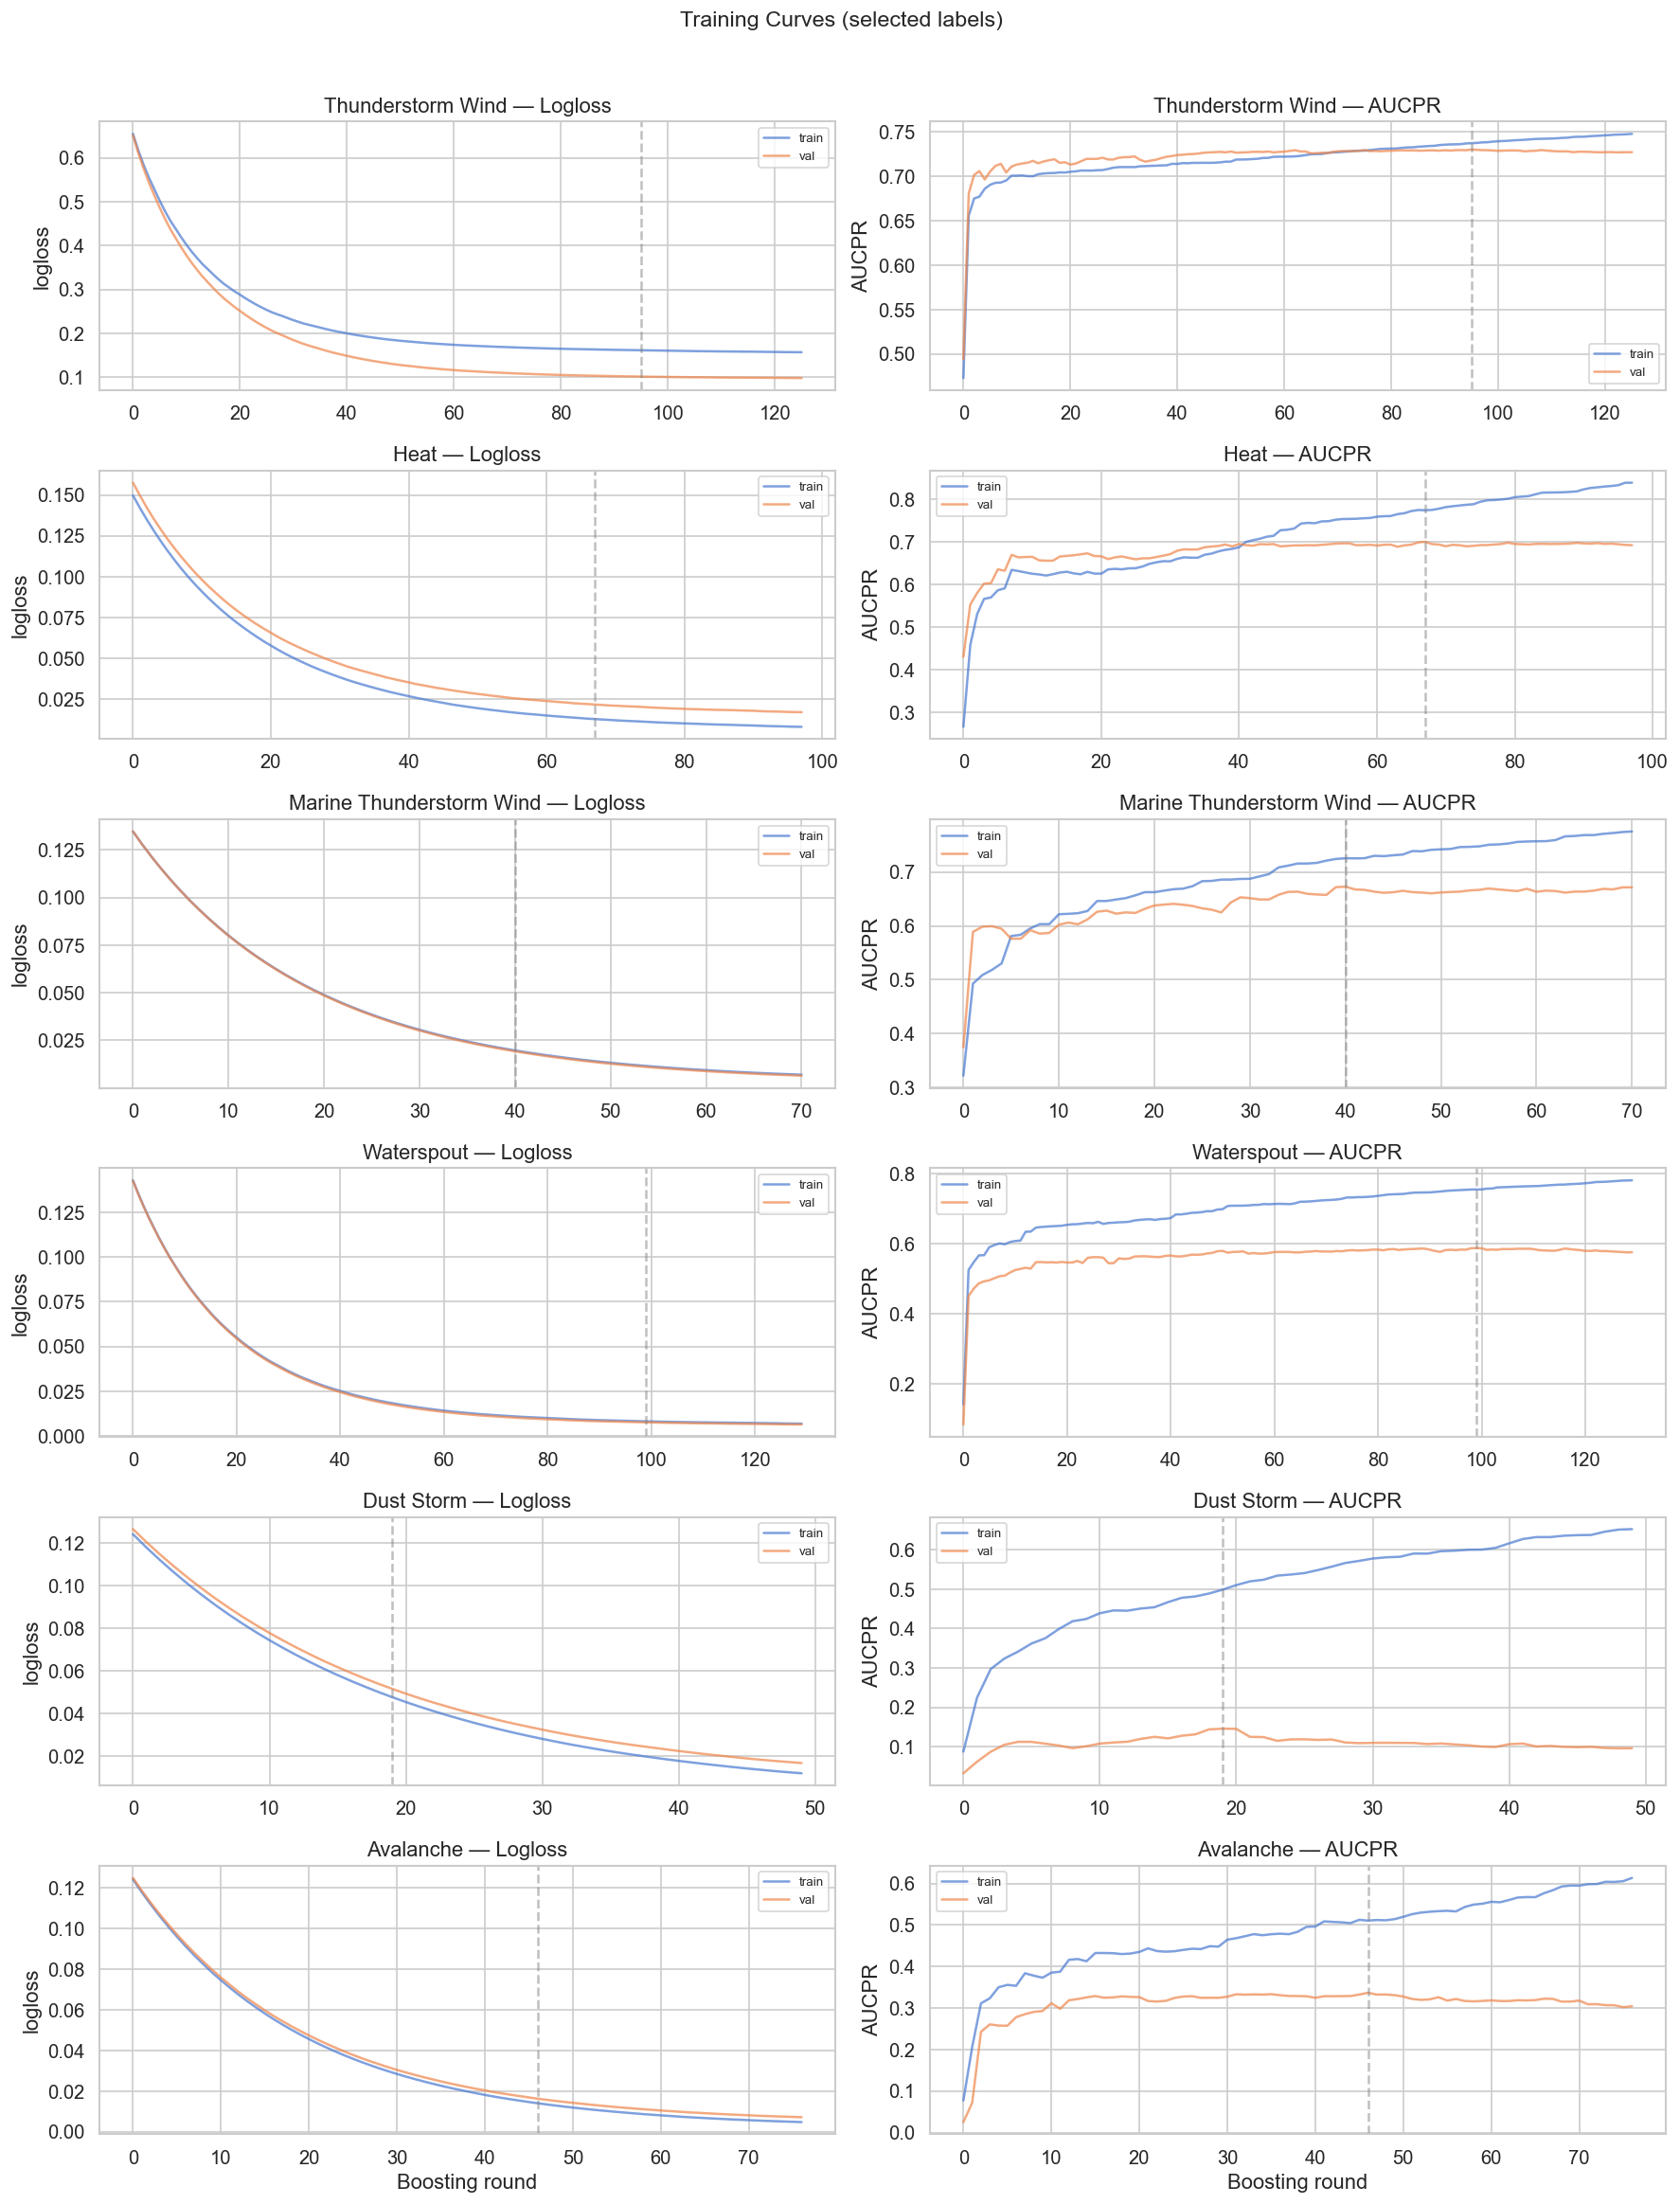

In [62]:
# Pick labels with highest val AUCPR to visualise (plus a few rare ones)
trained = summary_df[summary_df['status'] == 'trained'].copy()
top_labels   = trained.nlargest(4, 'best_val_aucpr')['label'].tolist()
rare_labels  = trained.nsmallest(2, 'n_pos')['label'].tolist()
plot_labels  = list(dict.fromkeys(top_labels + rare_labels))  # dedupe, keep order

n = len(plot_labels)
fig, axes = plt.subplots(n, 2, figsize=(15, 3.2 * n), sharex=False)
if n == 1:
    axes = axes.reshape(1, -1)

for row, label in enumerate(plot_labels):
    h = eval_histories[label]
    rounds = np.arange(len(h['validation_0']['logloss']))
    best_r = summary_df.loc[summary_df['label'] == label, 'best_round'].values[0]

    # Logloss
    ax = axes[row, 0]
    ax.plot(rounds, h['validation_0']['logloss'], label='train', alpha=.7)
    ax.plot(rounds, h['validation_1']['logloss'], label='val', alpha=.7)
    ax.axvline(best_r, ls='--', color='gray', alpha=.5)
    ax.set_ylabel('logloss')
    ax.set_title(f'{label} — Logloss')
    ax.legend(fontsize=8)

    # AUCPR
    ax = axes[row, 1]
    ax.plot(rounds, h['validation_0']['aucpr'], label='train', alpha=.7)
    ax.plot(rounds, h['validation_1']['aucpr'], label='val', alpha=.7)
    ax.axvline(best_r, ls='--', color='gray', alpha=.5)
    ax.set_ylabel('AUCPR')
    ax.set_title(f'{label} — AUCPR')
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Boosting round')

fig.suptitle('Training Curves (selected labels)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Importance
Averaged across all trained per-label models, plus a per-label breakdown for the top labels.

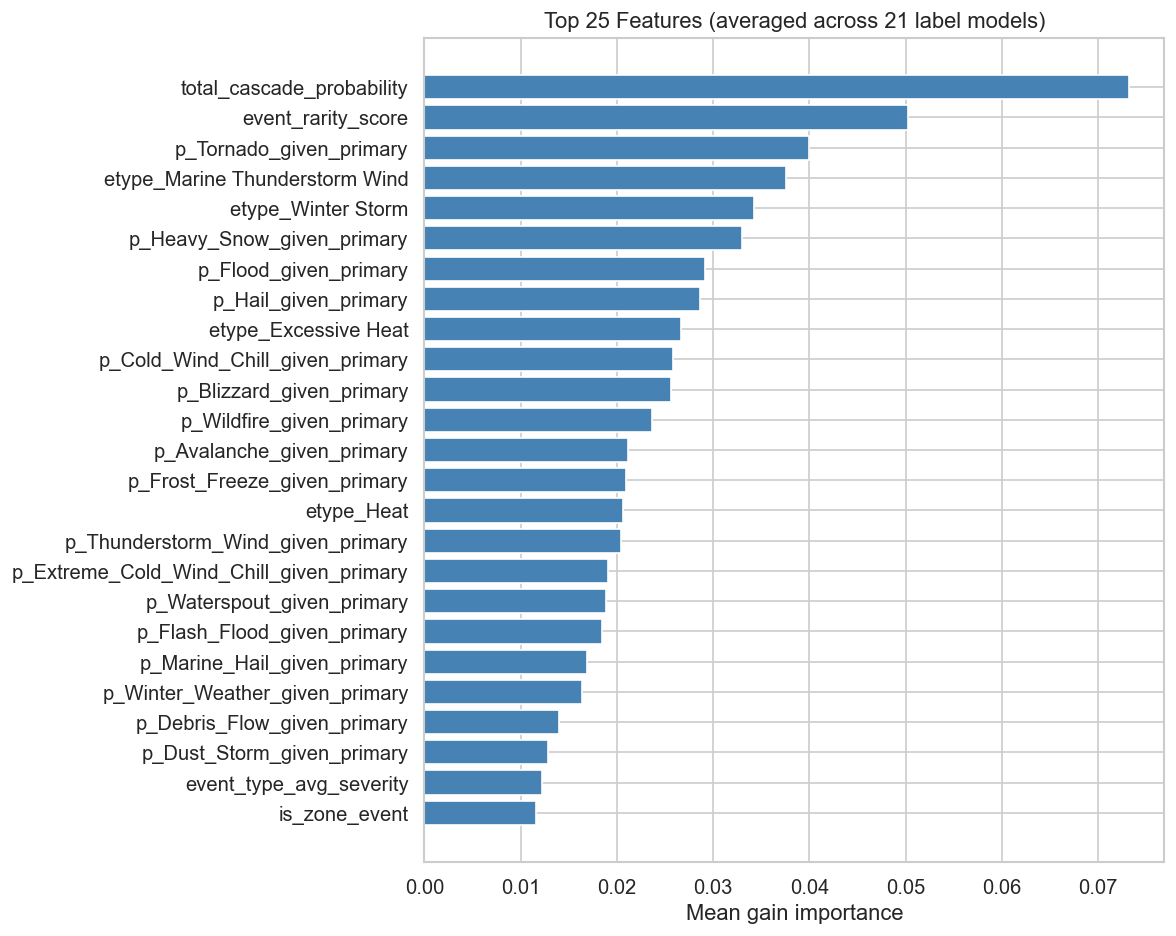

In [63]:
# --- Global average importance ---
imp_matrix = np.zeros((len(models), len(feature_names)))
for j, (lbl, mdl) in enumerate(models.items()):
    imp_matrix[j] = mdl.feature_importances_

avg_imp = imp_matrix.mean(axis=0)
top_k = 25
top_idx = np.argsort(avg_imp)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [feature_names[i] for i in reversed(top_idx)],
    [avg_imp[i] for i in reversed(top_idx)],
    color='steelblue'
)
ax.set_xlabel('Mean gain importance')
ax.set_title(f'Top {top_k} Features (averaged across {len(models)} label models)')
plt.tight_layout()
plt.show()

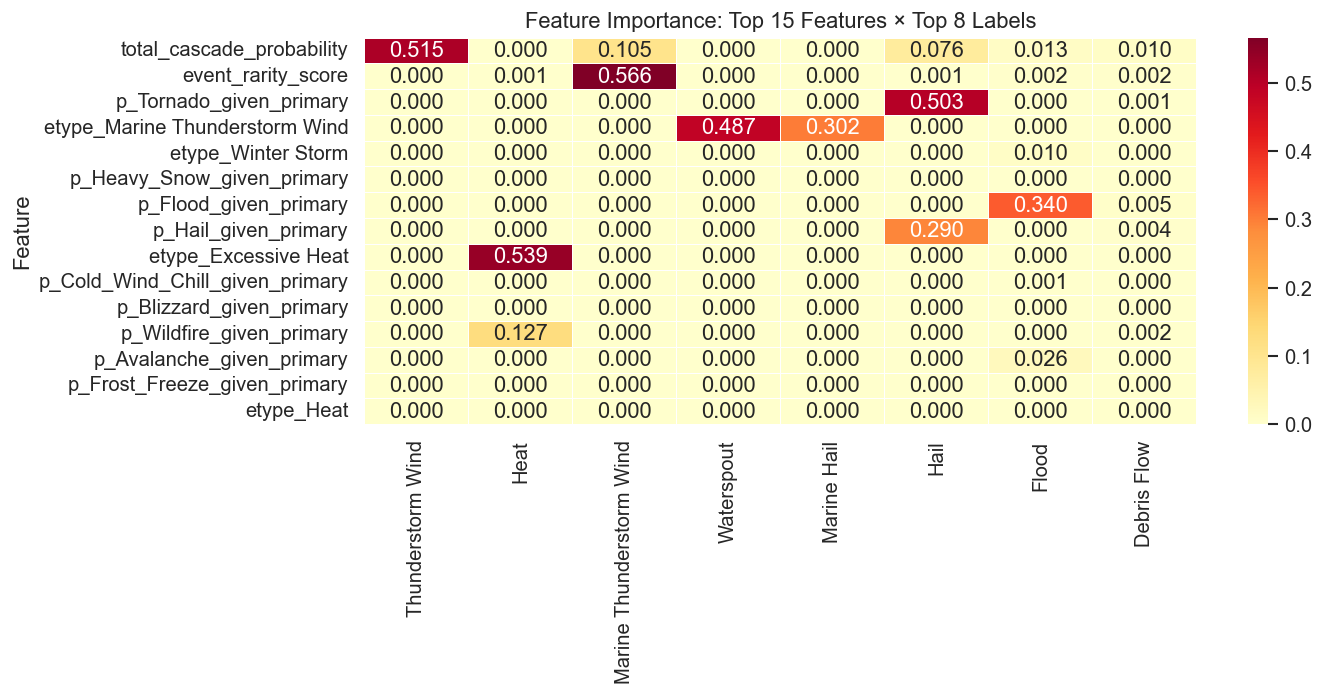

In [64]:
# --- Per-label importance heatmap (top features × top labels) ---
top_labels_for_heatmap = trained.nlargest(8, 'best_val_aucpr')['label'].tolist()
top_feat_idx = top_idx[:15]

heat_data = pd.DataFrame(
    {lbl: models[lbl].feature_importances_[top_feat_idx] for lbl in top_labels_for_heatmap},
    index=[feature_names[i] for i in top_feat_idx]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=.5)
ax.set_title('Feature Importance: Top 15 Features × Top 8 Labels')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Predict & Evaluate (default threshold = 0.5)

In [65]:
n_labels = len(target_names)
y_prob = np.zeros((X_test.shape[0], n_labels))
y_prob_val = np.zeros((X_val.shape[0], n_labels))

for i, label in enumerate(target_names):
    if label in models:
        y_prob[:, i] = models[label].predict_proba(X_test)[:, 1]
        y_prob_val[:, i] = models[label].predict_proba(X_val)[:, 1]

DEFAULT_THRESH = 0.5
y_pred_default = (y_prob >= DEFAULT_THRESH).astype(int)

In [66]:
def compute_all_metrics(y_true, y_pred, y_prob, target_names):
    """Return a dict of overall + per-label metrics."""
    overall = {
        'f1_macro':    f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_micro':    f1_score(y_true, y_pred, average='micro',    zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro',    zero_division=0),
        'hamming_loss':    hamming_loss(y_true, y_pred),
        'subset_accuracy': (y_true == y_pred).all(axis=1).mean(),
    }

    per_label = []
    for i, lbl in enumerate(target_names):
        sup = int(y_true[:, i].sum())
        if sup == 0:
            per_label.append(dict(label=lbl, support=0, f1=0, precision=0, recall=0, pr_auc=0))
            continue
        f1   = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
        rec  = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
        try:
            prauc = average_precision_score(y_true[:, i], y_prob[:, i])
        except Exception:
            prauc = 0.0
        per_label.append(dict(label=lbl, support=sup, f1=f1, precision=prec, recall=rec, pr_auc=prauc))

    return overall, pd.DataFrame(per_label)

overall_default, perlabel_default = compute_all_metrics(y_test, y_pred_default, y_prob, target_names)

print('=== Overall (threshold = 0.5) ===')
for k, v in overall_default.items():
    print(f'  {k:20s} {v:.4f}')

print('\n=== Per-label ===')
perlabel_default.sort_values('f1', ascending=False).style.format({
    'support': '{:,}', 'f1': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'pr_auc': '{:.3f}'
}).bar(subset=['f1'], color='#5fba7d')

=== Overall (threshold = 0.5) ===
  f1_macro             0.1719
  f1_micro             0.3718
  f1_weighted          0.4000
  precision_macro      0.1260
  recall_macro         0.3406
  hamming_loss         0.0245
  subset_accuracy      0.5978

=== Per-label ===


,label,support,f1,precision,recall,pr_auc
21,Thunderstorm Wind,"9,688",0.617,0.448,0.989,0.722
12,Heat,"2,406",0.505,0.388,0.724,0.536
19,Marine Thunderstorm Wind,169,0.486,0.340,0.852,0.502
11,Hail,"9,749",0.403,0.255,0.971,0.542
6,Excessive Heat,"3,070",0.403,0.410,0.396,0.388
23,Waterspout,286,0.372,0.237,0.871,0.640
9,Flood,"1,869",0.308,0.186,0.899,0.448
8,Flash Flood,"9,973",0.308,0.185,0.919,0.371
22,Tornado,"3,125",0.228,0.132,0.836,0.261
4,Debris Flow,292,0.178,0.143,0.233,0.093


## 7. Predicted-Probability Distributions
Histograms of predicted P(positive) for actual positives vs negatives.  
A well-calibrated model pushes these apart.

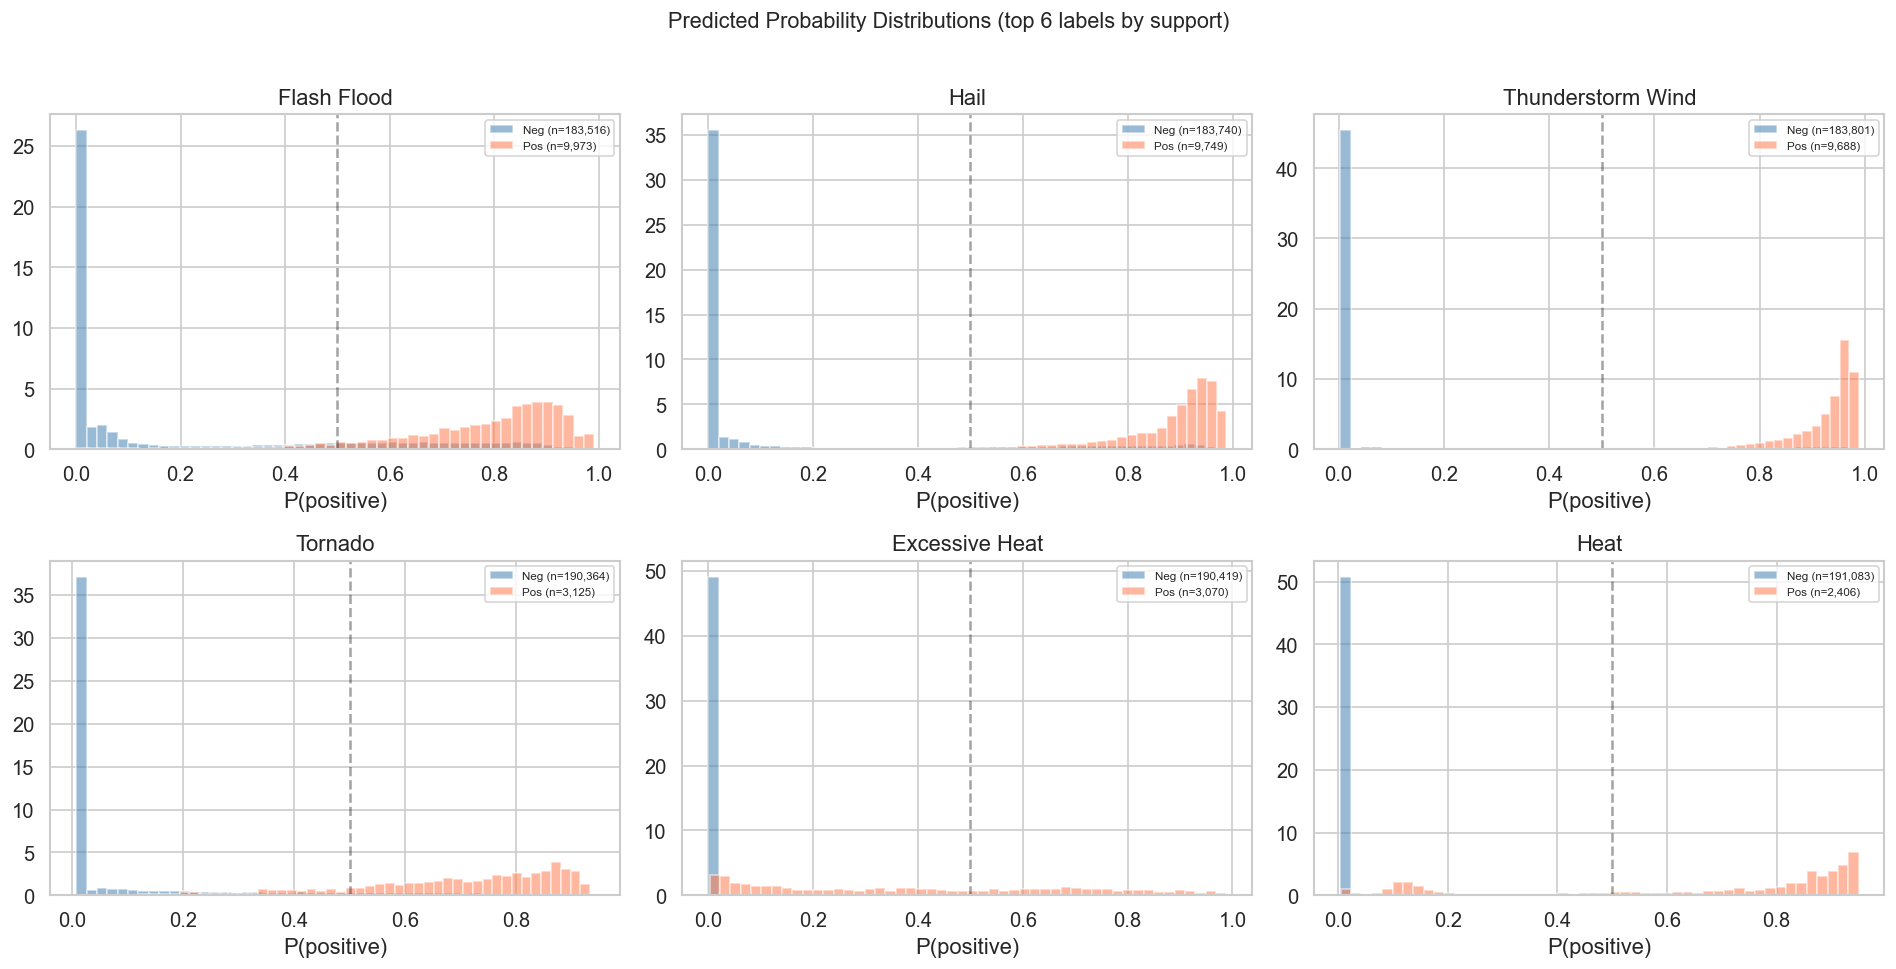

In [67]:
show_labels = perlabel_default.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.flat, show_labels):
    idx = target_names.index(label)
    pos_probs = y_prob[y_test[:, idx] == 1, idx]
    neg_probs = y_prob[y_test[:, idx] == 0, idx]

    ax.hist(neg_probs, bins=50, alpha=.55, label=f'Neg (n={len(neg_probs):,})', color='steelblue', density=True)
    ax.hist(pos_probs, bins=50, alpha=.55, label=f'Pos (n={len(pos_probs):,})', color='coral', density=True)
    ax.axvline(0.5, ls='--', color='k', alpha=.4)
    ax.set_title(label)
    ax.set_xlabel('P(positive)')
    ax.legend(fontsize=7)

fig.suptitle('Predicted Probability Distributions (top 6 labels by support)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Per-label Threshold Tuning (on validation set)
The default 0.5 threshold is usually not optimal for imbalanced labels.  
We sweep thresholds on the **validation set** precision-recall curve and pick the
one that maximises F1.  Thresholds are **never** tuned on test data to avoid leakage.

In [68]:
optimal_thresholds = np.full(n_labels, 0.5)

# Tune thresholds on VALIDATION set (not test) to avoid data leakage
for i, label in enumerate(target_names):
    if y_val[:, i].sum() == 0:
        continue
    precs, recs, threshs = precision_recall_curve(y_val[:, i], y_prob_val[:, i])
    f1s = 2 * precs * recs / (precs + recs + 1e-8)
    best = np.argmax(f1s)
    if best < len(threshs):
        optimal_thresholds[i] = threshs[best]

print("Tuned thresholds (from validation set):")
for lbl, thr in sorted(zip(target_names, optimal_thresholds), key=lambda x: x[1]):
    print(f"  {lbl:30s}  {thr:.4f}")

# Apply tuned thresholds to test set
y_pred_tuned = (y_prob >= optimal_thresholds).astype(int)

overall_tuned, perlabel_tuned = compute_all_metrics(y_test, y_pred_tuned, y_prob, target_names)

print('\n=== Overall (tuned thresholds, applied to test) ===')
for k, v in overall_tuned.items():
    print(f'  {k:20s} {v:.4f}')

print(f"\nF1 macro: {overall_default['f1_macro']:.4f}  ->  {overall_tuned['f1_macro']:.4f}")

Tuned thresholds (from validation set):
  Coastal Flood                   0.0000
  Frost/Freeze                    0.0000
  High Surf                       0.0000
  Winter Weather                  0.1182
  Ice Storm                       0.1352
  Cold/Wind Chill                 0.1702
  Extreme Cold/Wind Chill         0.2568
  Dust Storm                      0.3179
  Marine Hail                     0.3333
  Blizzard                        0.4387
  Heavy Rain                      0.5000
  Rip Current                     0.5000
  Heavy Snow                      0.5333
  Wildfire                        0.6051
  Avalanche                       0.6597
  Excessive Heat                  0.6708
  Tornado                         0.7348
  Debris Flow                     0.7717
  Lightning                       0.8020
  Marine Thunderstorm Wind        0.8107
  Flood                           0.8453
  Heat                            0.8476
  Flash Flood                     0.8687
  Thunderstorm Wi

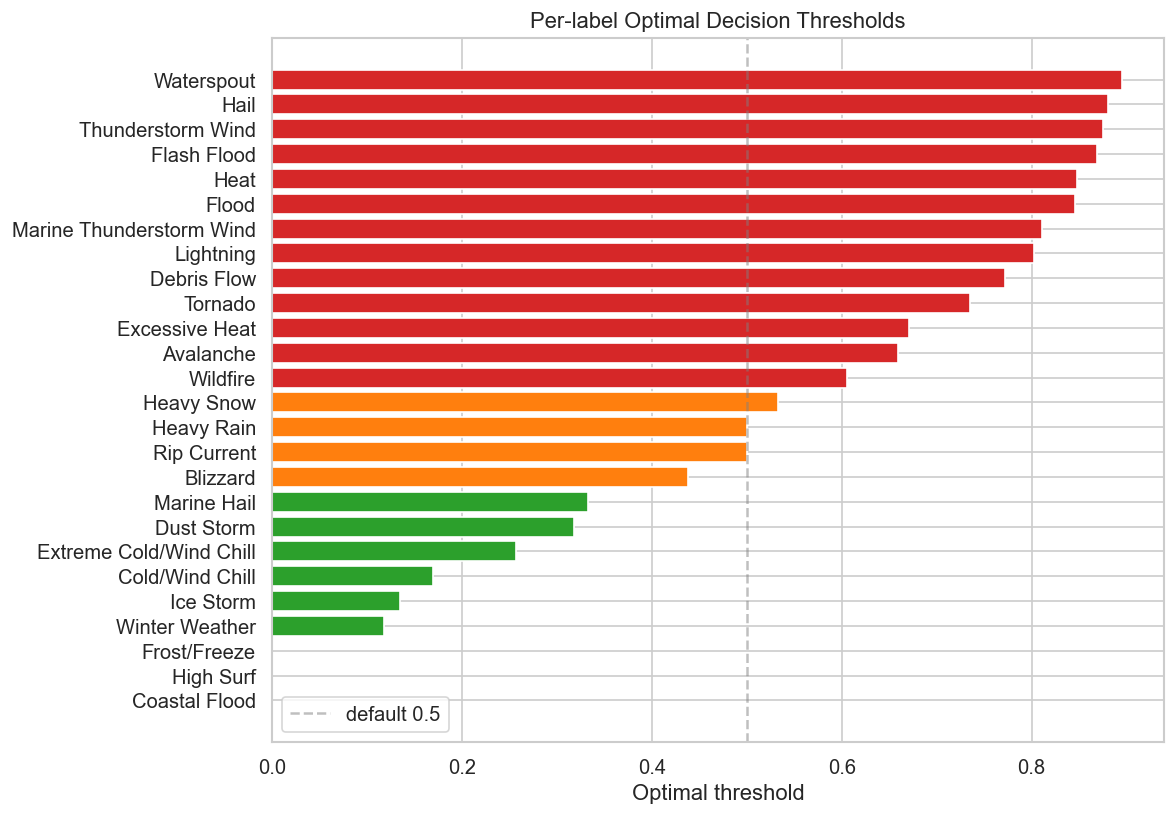

In [69]:
# --- Visualise optimal thresholds ---
thresh_df = pd.DataFrame({'label': target_names, 'threshold': optimal_thresholds})
thresh_df = thresh_df.sort_values('threshold', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ca02c' if t < 0.4 else '#ff7f0e' if t < 0.6 else '#d62728'
          for t in thresh_df['threshold']]
ax.barh(thresh_df['label'], thresh_df['threshold'], color=colors)
ax.axvline(0.5, ls='--', color='gray', alpha=.5, label='default 0.5')
ax.set_xlabel('Optimal threshold')
ax.set_title('Per-label Optimal Decision Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Comparison: Default vs Tuned Thresholds

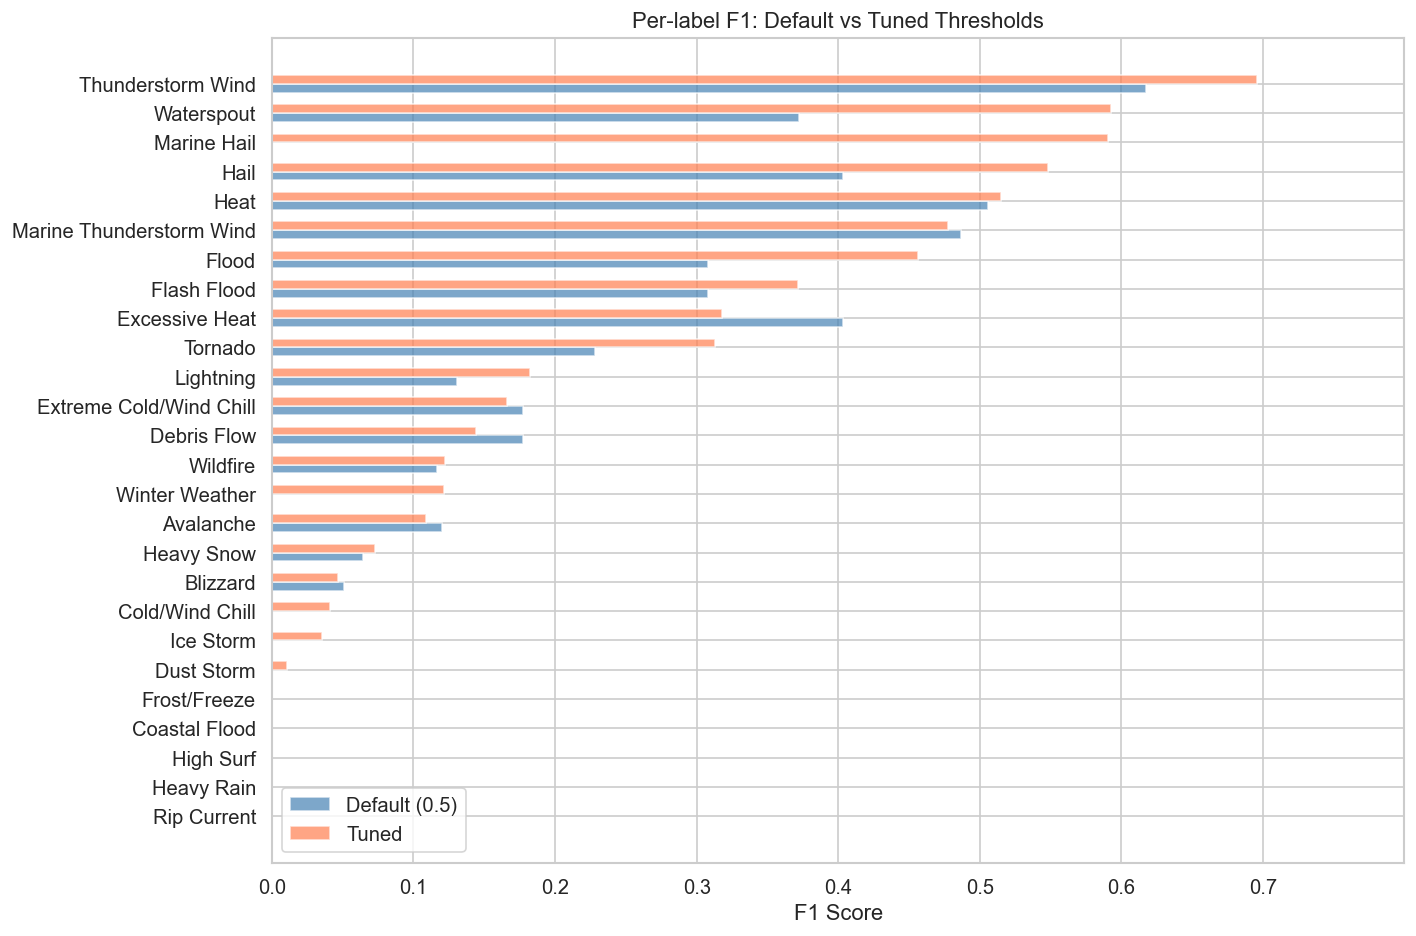

In [70]:
compare = perlabel_default[['label', 'f1']].rename(columns={'f1': 'f1_default'}).merge(
    perlabel_tuned[['label', 'f1']].rename(columns={'f1': 'f1_tuned'}),
    on='label'
)
compare['delta'] = compare['f1_tuned'] - compare['f1_default']
compare = compare.sort_values('f1_tuned', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(compare))
ax.barh(y_pos - 0.15, compare['f1_default'], height=0.3, label='Default (0.5)', color='steelblue', alpha=.7)
ax.barh(y_pos + 0.15, compare['f1_tuned'],   height=0.3, label='Tuned', color='coral', alpha=.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(compare['label'])
ax.set_xlabel('F1 Score')
ax.set_title('Per-label F1: Default vs Tuned Thresholds')
ax.legend()
ax.set_xlim(0, max(compare['f1_tuned'].max(), compare['f1_default'].max()) * 1.15)
plt.tight_layout()
plt.show()

## 10. Precision-Recall Curves

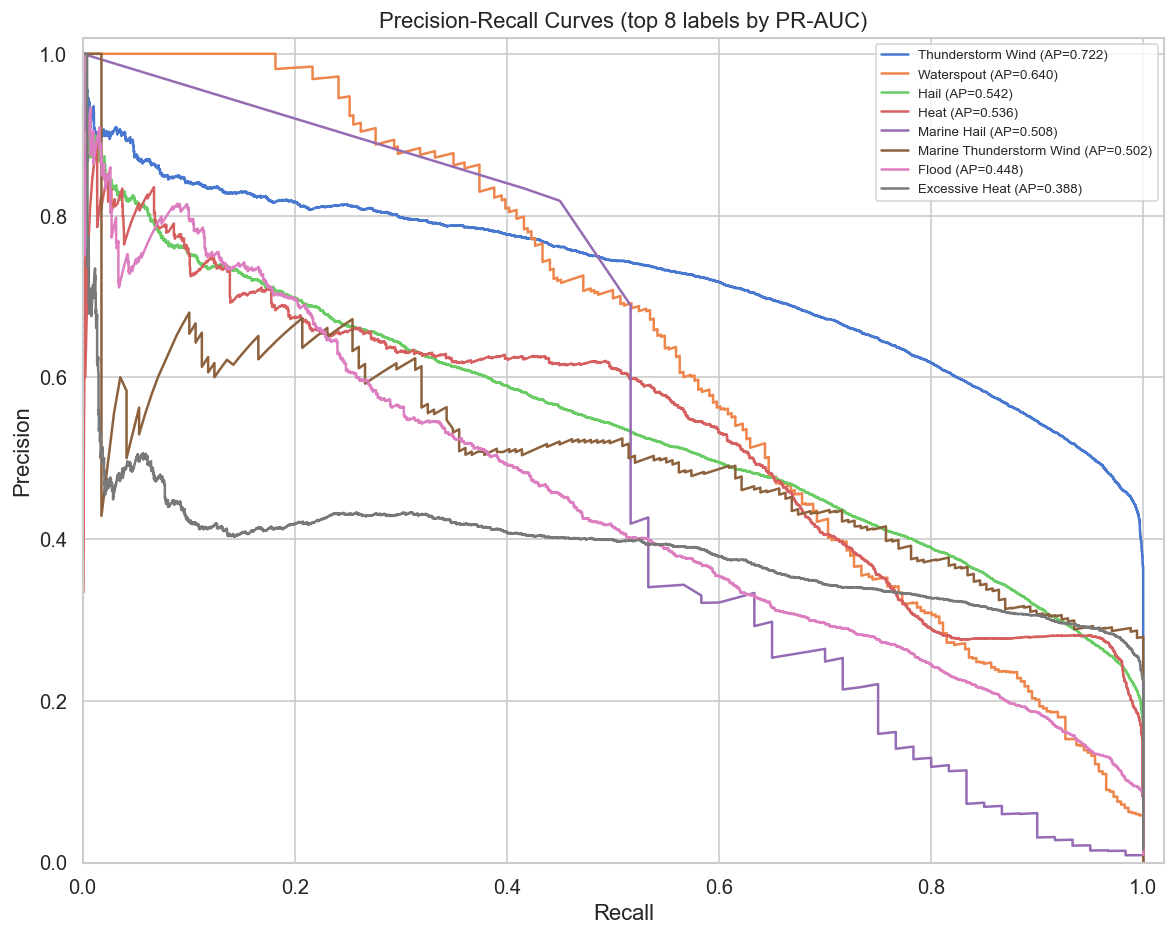

In [71]:
show_pr = perlabel_tuned.nlargest(8, 'pr_auc')['label'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for label in show_pr:
    idx = target_names.index(label)
    if y_test[:, idx].sum() == 0:
        continue
    precs, recs, _ = precision_recall_curve(y_test[:, idx], y_prob[:, idx])
    ap = average_precision_score(y_test[:, idx], y_prob[:, idx])
    ax.plot(recs, precs, label=f'{label} (AP={ap:.3f})', lw=1.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (top 8 labels by PR-AUC)')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 11. Confusion Matrices (top labels)

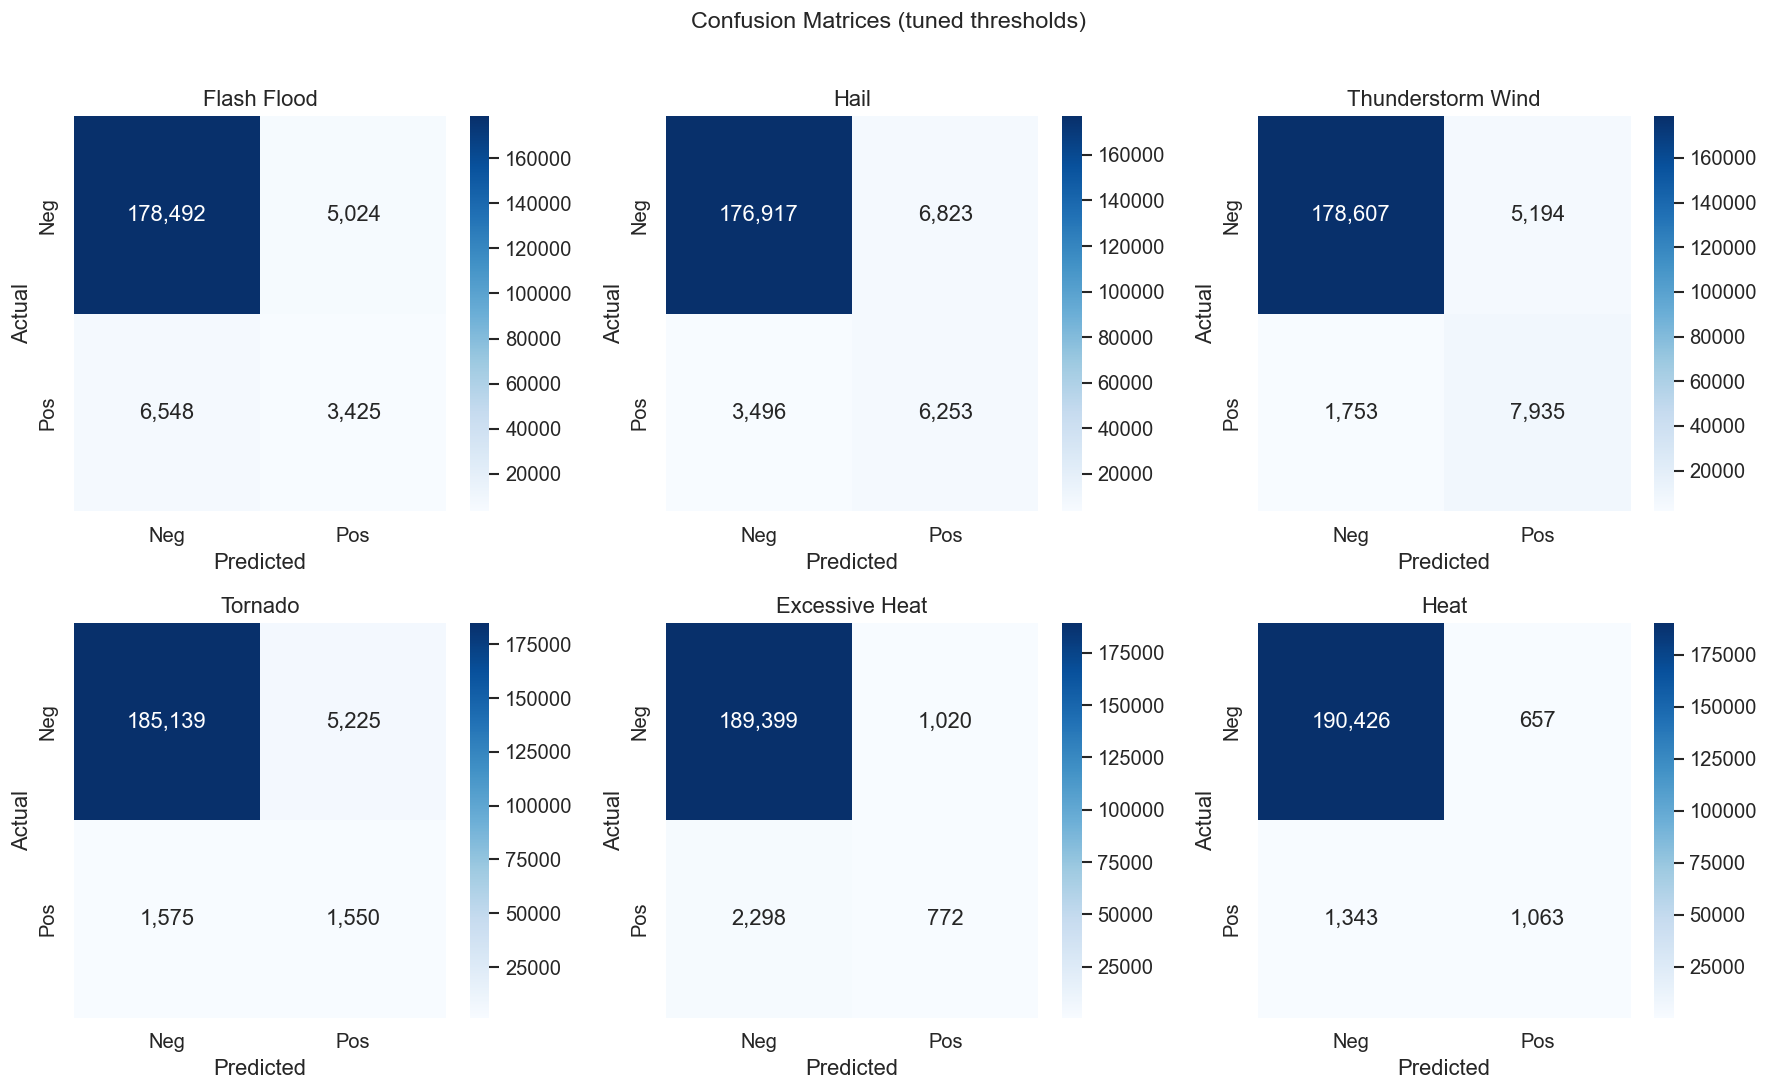

In [72]:
cm_labels = perlabel_tuned.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label in zip(axes.flat, cm_labels):
    idx = target_names.index(label)
    cm = confusion_matrix(y_test[:, idx], y_pred_tuned[:, idx])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(label)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices (tuned thresholds)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 12. Summary

In [73]:
# Pick the better result set
if overall_tuned['f1_macro'] >= overall_default['f1_macro']:
    final_overall, final_perlabel, final_pred = overall_tuned, perlabel_tuned, y_pred_tuned
    print('Using TUNED thresholds (better macro F1)\n')
else:
    final_overall, final_perlabel, final_pred = overall_default, perlabel_default, y_pred_default
    print('Using DEFAULT threshold 0.5 (better macro F1)\n')

print('╔══════════════════════════════════════╗')
print('║      Final Multilabel Results        ║')
print('╠══════════════════════════════════════╣')
for k, v in final_overall.items():
    print(f'║  {k:22s}  {v:>8.4f}  ║')
print('╚══════════════════════════════════════╝')

print('\nPer-label breakdown (sorted by F1):')
final_perlabel.sort_values('f1', ascending=False).head(10)

Using TUNED thresholds (better macro F1)

╔══════════════════════════════════════╗
║      Final Multilabel Results        ║
╠══════════════════════════════════════╣
║  f1_macro                  0.2281  ║
║  f1_micro                  0.0672  ║
║  f1_weighted               0.4761  ║
║  precision_macro           0.2386  ║
║  recall_macro              0.3863  ║
║  hamming_loss              0.1250  ║
║  subset_accuracy           0.0000  ║
╚══════════════════════════════════════╝

Per-label breakdown (sorted by F1):


,label,support,f1,precision,recall,pr_auc
21,Thunderstorm Wind,9688,0.695534,0.604387,0.819055,0.721970
23,Waterspout,286,0.592885,0.681818,0.524476,0.640210
18,Marine Hail,60,0.590476,0.688889,0.516667,0.508184
11,Hail,9749,0.547908,0.478204,0.641399,0.542352
12,Heat,2406,0.515269,0.618023,0.441812,0.535714
19,Marine Thunderstorm Wind,169,0.477707,0.517241,0.443787,0.501548
9,Flood,1869,0.456333,0.398403,0.533975,0.447803
8,Flash Flood,9973,0.371838,0.405373,0.343427,0.370785
6,Excessive Heat,3070,0.317565,0.430804,0.251466,0.387812
22,Tornado,3125,0.313131,0.228782,0.496000,0.260543


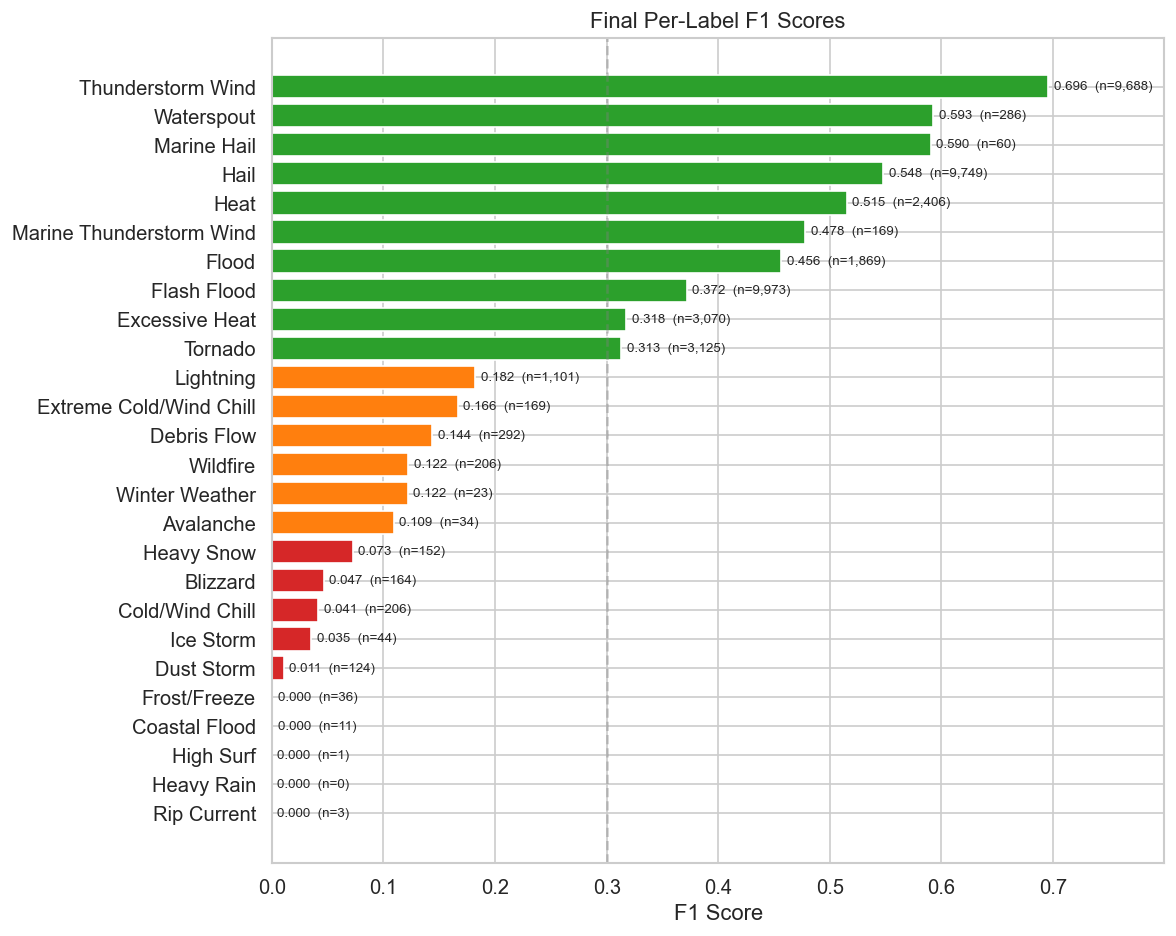

In [74]:
# --- Final bar chart ---
df_final = final_perlabel.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if f >= 0.3 else '#ff7f0e' if f >= 0.1 else '#d62728' for f in df_final['f1']]
ax.barh(df_final['label'], df_final['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Final Per-Label F1 Scores')
ax.axvline(0.3, ls='--', color='gray', alpha=.4)
ax.set_xlim(0, max(df_final['f1'].max() * 1.15, 0.5))

for i, (f1, sup) in enumerate(zip(df_final['f1'], df_final['support'])):
    ax.text(f1 + 0.005, i, f'{f1:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

*(Hyperparameter tuning was performed in Section 3 above — all results shown are from the tuned models.)*

In [75]:
# (HP search was done in cell above — this cell intentionally left empty)

In [76]:
# (Retrain was done in cell above — this cell intentionally left empty)

*(All evaluation was done in sections 6-12 above with the tuned models.)*

In [77]:
# (Evaluation was done in sections 6-12 above — this cell intentionally left empty)

In [78]:
# (Comparison plots are in sections 9 and 12 above — this cell intentionally left empty)